
# Entity Resolution POC — Raw → Rule Resolution/QC → Labels → Predictive Model

This notebook follows the practical sequence for a POC when the raw client file has candidate matches but no ground-truth labels:

```text
Raw file only
→ Option 2: rule-based entity resolution + QC
→ create resolved/QC output
→ use that output as labels
→ Option 1: predictive model
```

## What this solves

1. **Entity Resolution**: select the best candidate per input company or leave it unmatched/research-required.
2. **Data Analysis & QC**: flag inconsistencies in the selected match attributes.
3. **Predictive Modeling**: after creating a first-pass resolved output, convert it into labels and train a model.

> Important: the first generated labels are **first-pass rule/stewardship labels**, not independent human-reviewed ground truth. They are appropriate for a POC workflow and can later be replaced or improved with human-reviewed labels.


## 00. Setup

In [4]:

import re
import math
import warnings
from pathlib import Path
from urllib.parse import urlparse

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from rapidfuzz import fuzz
from sklearn.model_selection import GroupShuffleSplit, GroupKFold, cross_validate, GridSearchCV, learning_curve
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
    classification_report,
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)


## 00B. Auto-detect files and create project folders

In [5]:

# Auto-detect the raw Excel file from the current notebook folder.
# Put the notebook and raw .xlsx file in the same folder, then run all cells.
BASE_DIR = Path.cwd()
excel_files = [f for f in BASE_DIR.glob('*.xlsx') if not f.name.startswith('~$')]

if not excel_files:
    # Fallback for this hosted environment. Remove this block if running locally and you prefer strict current-folder behavior.
    BASE_DIR = Path('/mnt/data')
    excel_files = [f for f in BASE_DIR.glob('*.xlsx') if not f.name.startswith('~$')]

if not excel_files:
    raise FileNotFoundError(f'No .xlsx file found in current folder or /mnt/data.')

# Prefer the raw sample file over generated output files.
raw_keywords = ['presales_data_sample', 'data_sample', 'raw', 'sample']
exclude_keywords = ['resolved', 'qc', 'output', 'entity_resolution_final', 'medallion']

raw_candidates = [
    f for f in excel_files
    if any(k in f.name.lower() for k in raw_keywords)
    and not any(k in f.name.lower() for k in exclude_keywords)
]

INPUT_PATH = raw_candidates[0] if raw_candidates else excel_files[0]
print('Using raw input file:', INPUT_PATH)

PROJECT_DIR = BASE_DIR / 'entity_resolution_raw_to_ml'
BRONZE_DIR = PROJECT_DIR / 'bronze'
SILVER_DIR = PROJECT_DIR / 'silver'
GOLD_DIR = PROJECT_DIR / 'gold'
EXPORT_DIR = PROJECT_DIR / 'exports'
MODEL_DIR = PROJECT_DIR / 'models'
FIG_DIR = PROJECT_DIR / 'figures'

for p in [PROJECT_DIR, BRONZE_DIR, SILVER_DIR, GOLD_DIR, EXPORT_DIR, MODEL_DIR, FIG_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print('Project directory:', PROJECT_DIR)


Using raw input file: C:\Users\pauls\Downloads\data_analyst\presales_data_sample.xlsx
Project directory: C:\Users\pauls\Downloads\data_analyst\entity_resolution_raw_to_ml


## 01. Bronze — Raw Ingestion

In [6]:

bronze_candidates = pd.read_excel(INPUT_PATH, sheet_name=0)
bronze_candidates['bronze_ingested_at_utc'] = pd.Timestamp.utcnow().tz_localize(None)
bronze_candidates['source_file'] = INPUT_PATH.name
bronze_candidates['source_sheet'] = 'Sheet1'

bronze_candidates.to_csv(BRONZE_DIR / 'bronze_candidates_raw.csv', index=False)
bronze_candidates.to_pickle(BRONZE_DIR / 'bronze_candidates_raw.pkl')

print('Raw shape:', bronze_candidates.shape)
bronze_candidates.head(3)


Raw shape: (2951, 79)


,input_row_key,input_company_name,input_main_country_code,input_main_country,input_main_region,input_main_city,input_main_postcode,input_main_street,input_main_street_number,veridion_id,company_name,company_legal_names,company_commercial_names,main_country_code,main_country,main_region,main_city,main_postcode,main_street,main_street_number,main_latitude,main_longitude,locations,num_locations,company_type,year_founded,revenue,revenue_type,employee_count,employee_count_type,generated_description,generated_business_tags,short_description,long_description,business_tags,naics_2022_primary_code,naics_2022_primary_label,naics_2022_secondary_codes,naics_2022_secondary_labels,main_business_category,main_industry,main_sector,sics_codified_industry,sics_codified_industry_code,sics_codified_subsector,sics_codified_subsector_code,sics_codified_sector,sics_codified_sector_code,sic_codes,sic_labels,ibc_insurance_labels,isic_v4_codes,isic_v4_labels,nace_rev2_codes,nace_rev2_labels,ibc_insurance_codes,primary_phone,phone_numbers,primary_email,emails,other_emails,website_url,website_domain,website_tld,website_language_code,facebook_url,twitter_url,instagram_url,linkedin_url,ios_app_url,android_app_url,youtube_url,tiktok_url,technologies,created_at,last_updated_at,bronze_ingested_at_utc,source_file,source_sheet
0,0,24-SEVEN MEDIA NETWORK (PRIVATE) LIMITED,PK,Pakistan,Sindh,Karachi,NaN,NaN,NaN,26e22210-93e5-11eb-b997-8dd98d09cf25,New Millennium Network,New Millennium Network Private Limited | MNET ...,New Millennium Network,PK,Pakistan,Sindh,Karachi,74400,NaN,NaN,NaN,NaN,"PK, Pakistan, Sindh, Karachi, 74400, , , 24.85...",1.0,Private,2001.0,311793.0,modelled,23.0,extracted,"MNET, incorporated in 2001, is a Pakistani com...",Mobile Top-up Services | Website Development |...,"Incorporated in 2001, MNET is the first compan...","Incorporated in 2001, MNET is the first compan...",Transfer Funds | Shop & Products | Managed Ser...,517810.0,All Other Telecommunications,NaN,NaN,Cable & Internet Providers,Telecommunication Services,IT&C Services,Media & Entertainment,SV-ME,Media,SV.1,Services,SV,7375 | 4899,Information Retrieval Services (Internet servi...,NaN,6190,Other telecommunications activities,61.9,Other telecommunications activities,NaN,9.233351e+11,+923335055787,NaN,NaN,NaN,https://www.mnet.com.pk/,mnet.com.pk,com.pk,en,NaN,NaN,NaN,http://www.linkedin.com/company/mnet-services-...,NaN,NaN,NaN,NaN,web servers: apache http server - 2 | javascri...,2020-02-25T14:47:51.000Z,2024-11-29T04:18:00.109Z,2026-05-11 06:58:12.319729,presales_data_sample.xlsx,Sheet1
1,0,24-SEVEN MEDIA NETWORK (PRIVATE) LIMITED,PK,Pakistan,Sindh,Karachi,NaN,NaN,NaN,01004641-1dd8-11ef-9268-316fc8e174dd,Private Helipad Ali Villa,NaN,Private Helipad Ali Villa,PK,Pakistan,Sindh,Karachi,74400,NaN,NaN,NaN,NaN,"PK, Pakistan, Sindh, Karachi, 74400, , , 25.03...",1.0,NaN,NaN,NaN,NaN,NaN,NaN,The Private Helipad Ali Villa is a heliport lo...,Air Transportation Services | Heliport Services,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-05-29T16:24:11.019Z,2025-04-20T15:03:24.026Z,2026-05-11 06:58:12.319729,presales_data_sample.xlsx,Sheet1
2,0,24-SEVEN MEDIA NETWORK (PRIVATE) LIMITED,PK,Pakistan,Sindh,Karachi,NaN,NaN,NaN,8266efc1-13e7-11ec-aa14-7bf90e1e10f1,24seven Research Network,NaN,24seven Research Network,IN,India,Haryana,Faridabad,121001,Gurunanak Gali No. 3,3071,28.399705,77.286203,"IN, India, Haryana, Faridabad, 121001, Gurunan...",1.0,Private,NaN,518659.0,modelled,75.0,modelled,24seven Research Network is a market research ...,Market Research Services | Data Collection Ser...,We are the fastest growing market research com...,"With a team of highly skilled, qualified and m...",NaN,541910.0,Marketing Research and Public Opinion Polling,NaN,NaN,Market Research & Opinion Polling,Marketing & Advertising Agencies,Advertising & Marketing,Advertising & Marketing,SV-

## 02. Bronze — Profiling + Visualizations

In [7]:

bronze_profile = pd.DataFrame({
    'column_name': bronze_candidates.columns,
    'dtype': [str(x) for x in bronze_candidates.dtypes],
    'non_null_count': bronze_candidates.notna().sum().values,
    'missing_count': bronze_candidates.isna().sum().values,
})
bronze_profile['missing_pct'] = bronze_profile['missing_count'] / len(bronze_candidates)

bronze_candidate_counts = (
    bronze_candidates.groupby('input_row_key', dropna=False)
    .size()
    .reset_index(name='candidate_count')
)

bronze_inputs = bronze_candidates[[
    'input_row_key', 'input_company_name', 'input_main_country_code', 'input_main_country',
    'input_main_region', 'input_main_city', 'input_main_postcode', 'input_main_street', 'input_main_street_number'
]].drop_duplicates('input_row_key').reset_index(drop=True)

bronze_profile.to_csv(BRONZE_DIR / 'bronze_profile.csv', index=False)
bronze_candidate_counts.to_csv(BRONZE_DIR / 'bronze_candidate_counts.csv', index=False)
bronze_inputs.to_csv(BRONZE_DIR / 'bronze_inputs.csv', index=False)

print('Unique input companies:', bronze_inputs['input_row_key'].nunique())
print('Candidate rows:', len(bronze_candidates))
bronze_profile.head()


Unique input companies: 592
Candidate rows: 2951


,column_name,dtype,non_null_count,missing_count,missing_pct
0,input_row_key,int64,2951,0,0.000000
1,input_company_name,str,2951,0,0.000000
2,input_main_country_code,str,2951,0,0.000000
3,input_main_country,str,2951,0,0.000000
4,input_main_region,str,2616,335,0.113521


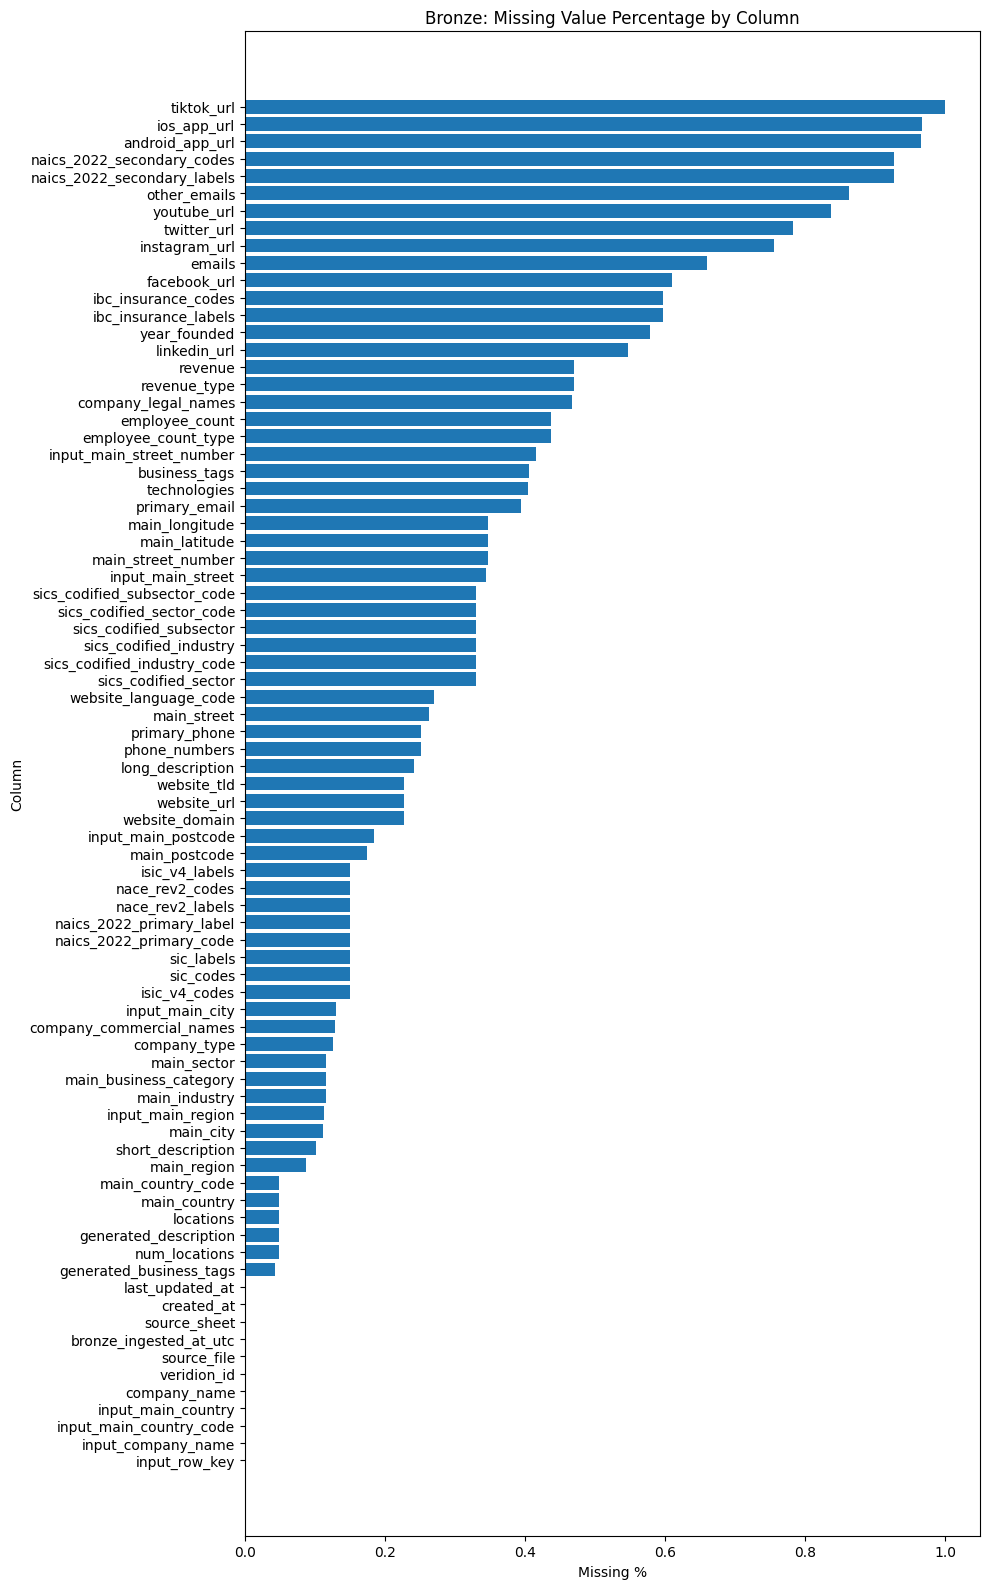

In [8]:

# Visualization: missing values by column
missing_plot_df = bronze_profile.sort_values('missing_pct', ascending=True)
plt.figure(figsize=(10, 16))
plt.barh(missing_plot_df['column_name'], missing_plot_df['missing_pct'])
plt.xlabel('Missing %')
plt.ylabel('Column')
plt.title('Bronze: Missing Value Percentage by Column')
plt.tight_layout()
plt.savefig(FIG_DIR / 'bronze_missing_values.png', dpi=150)
plt.show()


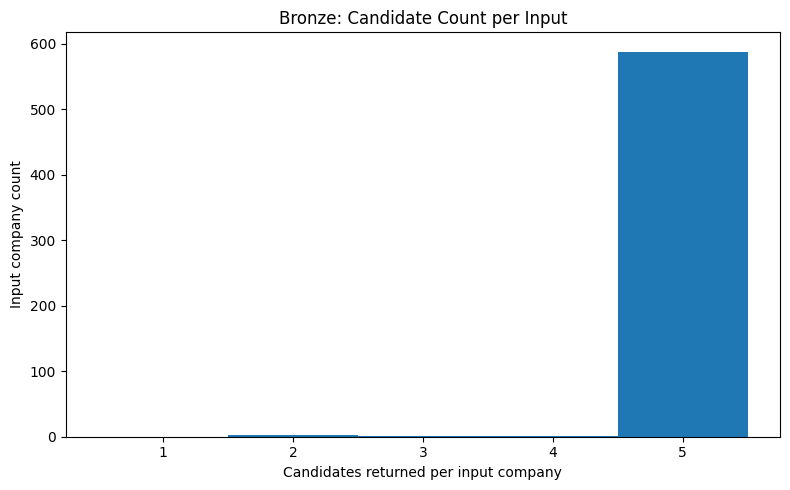

In [9]:

# Visualization: candidate count per input company
plt.figure(figsize=(8, 5))
plt.hist(bronze_candidate_counts['candidate_count'], bins=range(1, int(bronze_candidate_counts['candidate_count'].max()) + 2), align='left')
plt.xlabel('Candidates returned per input company')
plt.ylabel('Input company count')
plt.title('Bronze: Candidate Count per Input')
plt.tight_layout()
plt.savefig(FIG_DIR / 'bronze_candidate_count.png', dpi=150)
plt.show()


## 03. Silver — Helper functions for standardization and matching

In [10]:

LEGAL_SUFFIXES = {
    'ltd','limited','inc','incorporated','corp','corporation','co','company','llc','plc',
    'gmbh','ag','sa','srl','s.r.l','bv','nv','sas','oy','ab','as','spa','kft','kg',
    'pte','pty','zoo','sp','doo','sro','s.a','s.p.a','pte.','pty.'
}


def safe_str(x):
    return '' if pd.isna(x) else str(x)


def normalize_whitespace(text):
    return re.sub(r'\s+', ' ', safe_str(text)).strip()


def normalize_company_name(text):
    text = safe_str(text).lower().replace('&', ' and ')
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = normalize_whitespace(text)
    tokens = [t for t in text.split() if t not in LEGAL_SUFFIXES]
    return ' '.join(tokens)


def extract_tokens(text):
    return [t for t in normalize_company_name(text).split() if t]


def extract_domain(value):
    text = safe_str(value).strip().lower()
    if not text:
        return ''
    if '://' not in text and '.' in text:
        text = 'http://' + text
    try:
        netloc = urlparse(text).netloc.lower().replace('www.', '')
        return netloc
    except Exception:
        return ''


def domain_root(domain):
    domain = extract_domain(domain)
    if not domain:
        return ''
    parts = domain.split('.')
    return parts[-2] if len(parts) >= 2 else parts[0]


def clean_country_code(x):
    x = safe_str(x).strip().upper()
    return x[:2] if x else ''


def coalesce_name_variants(row):
    variants = [
        safe_str(row.get('company_name')),
        safe_str(row.get('company_legal_names')),
        safe_str(row.get('company_commercial_names')),
    ]
    variants = [v for v in variants if v and v.lower() != 'nan']
    return ' | '.join(dict.fromkeys(variants))


def token_overlap_ratio(a, b):
    set_a, set_b = set(extract_tokens(a)), set(extract_tokens(b))
    if not set_a or not set_b:
        return 0.0
    return len(set_a & set_b) / len(set_a | set_b)


def weighted_token_overlap(a, b, rarity_map):
    set_a, set_b = set(extract_tokens(a)), set(extract_tokens(b))
    union = set_a | set_b
    inter = set_a & set_b
    if not union:
        return 0.0
    return sum(rarity_map.get(t, 1.0) for t in inter) / sum(rarity_map.get(t, 1.0) for t in union)


## 04. Silver — Standardization and feature engineering

### Silver 1 — Create working table

In [11]:

silver = bronze_candidates.copy()
silver['candidate_rank_from_engine'] = silver.groupby('input_row_key').cumcount() + 1
silver['candidate_name_variants'] = silver.apply(coalesce_name_variants, axis=1)
silver['input_company_name_raw'] = silver['input_company_name']
silver['candidate_company_name_raw'] = silver['company_name']
silver.head(2)


,input_row_key,input_company_name,input_main_country_code,input_main_country,input_main_region,input_main_city,input_main_postcode,input_main_street,input_main_street_number,veridion_id,company_name,company_legal_names,company_commercial_names,main_country_code,main_country,main_region,main_city,main_postcode,main_street,main_street_number,main_latitude,main_longitude,locations,num_locations,company_type,year_founded,revenue,revenue_type,employee_count,employee_count_type,generated_description,generated_business_tags,short_description,long_description,business_tags,naics_2022_primary_code,naics_2022_primary_label,naics_2022_secondary_codes,naics_2022_secondary_labels,main_business_category,main_industry,main_sector,sics_codified_industry,sics_codified_industry_code,sics_codified_subsector,sics_codified_subsector_code,sics_codified_sector,sics_codified_sector_code,sic_codes,sic_labels,ibc_insurance_labels,isic_v4_codes,isic_v4_labels,nace_rev2_codes,nace_rev2_labels,ibc_insurance_codes,primary_phone,phone_numbers,primary_email,emails,other_emails,website_url,website_domain,website_tld,website_language_code,facebook_url,twitter_url,instagram_url,linkedin_url,ios_app_url,android_app_url,youtube_url,tiktok_url,technologies,created_at,last_updated_at,bronze_ingested_at_utc,source_file,source_sheet,candidate_rank_from_engine,candidate_name_variants,input_company_name_raw,candidate_company_name_raw
0,0,24-SEVEN MEDIA NETWORK (PRIVATE) LIMITED,PK,Pakistan,Sindh,Karachi,NaN,NaN,NaN,26e22210-93e5-11eb-b997-8dd98d09cf25,New Millennium Network,New Millennium Network Private Limited | MNET ...,New Millennium Network,PK,Pakistan,Sindh,Karachi,74400,NaN,NaN,NaN,NaN,"PK, Pakistan, Sindh, Karachi, 74400, , , 24.85...",1.0,Private,2001.0,311793.0,modelled,23.0,extracted,"MNET, incorporated in 2001, is a Pakistani com...",Mobile Top-up Services | Website Development |...,"Incorporated in 2001, MNET is the first compan...","Incorporated in 2001, MNET is the first compan...",Transfer Funds | Shop & Products | Managed Ser...,517810.0,All Other Telecommunications,NaN,NaN,Cable & Internet Providers,Telecommunication Services,IT&C Services,Media & Entertainment,SV-ME,Media,SV.1,Services,SV,7375 | 4899,Information Retrieval Services (Internet servi...,NaN,6190,Other telecommunications activities,61.9,Other telecommunications activities,NaN,9.233351e+11,+923335055787,NaN,NaN,NaN,https://www.mnet.com.pk/,mnet.com.pk,com.pk,en,NaN,NaN,NaN,http://www.linkedin.com/company/mnet-services-...,NaN,NaN,NaN,NaN,web servers: apache http server - 2 | javascri...,2020-02-25T14:47:51.000Z,2024-11-29T04:18:00.109Z,2026-05-11 06:58:12.319729,presales_data_sample.xlsx,Sheet1,1,New Millennium Network | New Millennium Networ...,24-SEVEN MEDIA NETWORK (PRIVATE) LIMITED,New Millennium Network
1,0,24-SEVEN MEDIA NETWORK (PRIVATE) LIMITED,PK,Pakistan,Sindh,Karachi,NaN,NaN,NaN,01004641-1dd8-11ef-9268-316fc8e174dd,Private Helipad Ali Villa,NaN,Private Helipad Ali Villa,PK,Pakistan,Sindh,Karachi,74400,NaN,NaN,NaN,NaN,"PK, Pakistan, Sindh, Karachi, 74400, , , 25.03...",1.0,NaN,NaN,NaN,NaN,NaN,NaN,The Private Helipad Ali Villa is a heliport lo...,Air Transportation Services | Heliport Services,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2024-05-29T16:24:11.019Z,2025-04-20T15:03:24.026Z,2026-05-11 06:58:12.319729,presales_data_sample.xlsx,Sheet1,2,Private Helipad Ali Villa,24-SEVEN MEDIA NETWORK (PRIVATE) LIMITED,Private Helipad Ali Villa


### Silver 2 — Normalize company names

In [12]:

silver['input_name_norm'] = silver['input_company_name_raw'].apply(normalize_company_name)
silver['candidate_name_norm'] = silver['candidate_company_name_raw'].apply(normalize_company_name)
silver['candidate_variants_norm'] = silver['candidate_name_variants'].apply(normalize_company_name)
silver[['input_company_name_raw','input_name_norm','candidate_company_name_raw','candidate_name_norm']].head()


,input_company_name_raw,input_name_norm,candidate_company_name_raw,candidate_name_norm
0,24-SEVEN MEDIA NETWORK (PRIVATE) LIMITED,24 seven media network private,New Millennium Network,new millennium network
1,24-SEVEN MEDIA NETWORK (PRIVATE) LIMITED,24 seven media network private,Private Helipad Ali Villa,private helipad ali villa
2,24-SEVEN MEDIA NETWORK (PRIVATE) LIMITED,24 seven media network private,24seven Research Network,24seven research network
3,24-SEVEN MEDIA NETWORK (PRIVATE) LIMITED,24 seven media network private,EmerioSoft,emeriosoft
4,24-SEVEN MEDIA NETWORK (PRIVATE) LIMITED,24 seven media network private,Asiatic Public Relations Network,asiatic public relations network


### Silver 3 — Name similarity features

In [13]:

silver['name_ratio'] = silver.apply(lambda r: fuzz.ratio(r['input_name_norm'], r['candidate_name_norm']) / 100, axis=1)
silver['partial_ratio'] = silver.apply(lambda r: fuzz.partial_ratio(r['input_name_norm'], r['candidate_name_norm']) / 100, axis=1)
silver['token_sort_ratio'] = silver.apply(lambda r: fuzz.token_sort_ratio(r['input_name_norm'], r['candidate_name_norm']) / 100, axis=1)
silver['token_set_ratio'] = silver.apply(lambda r: fuzz.token_set_ratio(r['input_name_norm'], r['candidate_name_norm']) / 100, axis=1)
silver['variant_ratio'] = silver.apply(lambda r: fuzz.token_set_ratio(r['input_name_norm'], r['candidate_variants_norm']) / 100, axis=1)
silver['exact_normalized_name_match'] = (silver['input_name_norm'] == silver['candidate_name_norm']).astype(int)
silver['token_overlap_ratio'] = silver.apply(lambda r: token_overlap_ratio(r['input_name_norm'], r['candidate_name_norm']), axis=1)
silver[['name_ratio','partial_ratio','token_sort_ratio','token_set_ratio','variant_ratio','token_overlap_ratio']].describe()


,name_ratio,partial_ratio,token_sort_ratio,token_set_ratio,variant_ratio,token_overlap_ratio
count,2951.000000,2951.000000,2951.000000,2951.000000,2951.000000,2951.00000
mean,0.571863,0.761887,0.563177,0.702101,0.751454,0.32416
std,0.242626,0.243389,0.241865,0.291346,0.243052,0.30638
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,0.377868,0.577778,0.370370,0.461538,0.577778,0.00000
50%,0.560000,0.809524,0.545455,0.740741,0.785714,0.25000
75%,0.750000,1.000000,0.733333,1.000000,1.000000,0.50000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


### Silver 4 — Rare-token features

In [14]:

all_tokens = silver['candidate_name_norm'].apply(extract_tokens)
token_freq = pd.Series([t for toks in all_tokens for t in toks]).value_counts()
rarity_map = {tok: 1.0 / math.log1p(freq + 1) for tok, freq in token_freq.items()}

silver['weighted_token_overlap'] = silver.apply(lambda r: weighted_token_overlap(r['input_name_norm'], r['candidate_name_norm'], rarity_map), axis=1)
silver['rare_token_match_count'] = silver.apply(
    lambda r: sum(1 for t in set(extract_tokens(r['input_name_norm'])) & set(extract_tokens(r['candidate_name_norm'])) if rarity_map.get(t, 0) > 0.4),
    axis=1,
)
silver[['weighted_token_overlap','rare_token_match_count']].describe()


,weighted_token_overlap,rare_token_match_count
count,2951.000000,2951.000000
mean,0.320691,0.651305
std,0.315764,0.706434
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.242089,1.000000
75%,0.505512,1.000000
max,1.000000,8.000000


### Silver 5 — Domain features

In [15]:

silver['candidate_domain'] = silver['website_domain'].apply(extract_domain)
silver['candidate_domain_root'] = silver['candidate_domain'].apply(domain_root)
silver['candidate_has_website'] = silver['candidate_domain'].ne('').astype(int)
silver['candidate_has_linkedin'] = silver['linkedin_url'].notna().astype(int)
silver['domain_root_matches_input_token'] = silver.apply(
    lambda r: int(r['candidate_domain_root'] in set(extract_tokens(r['input_name_norm'])) if r['candidate_domain_root'] else 0),
    axis=1,
)
silver[['candidate_domain','candidate_domain_root','candidate_has_website','domain_root_matches_input_token']].head()


,candidate_domain,candidate_domain_root,candidate_has_website,domain_root_matches_input_token
0,mnet.com.pk,com,1,0
1,,,0,0
2,24sevenresearchnetwork.com,24sevenresearchnetwork,1,0
3,emeriosoft.com,emeriosoft,1,0
4,apr.com.pk,com,1,0


### Silver 6 — Geography features

In [16]:

silver['input_country_code_norm'] = silver['input_main_country_code'].apply(clean_country_code)
silver['candidate_country_code_norm'] = silver['main_country_code'].apply(clean_country_code)
silver['same_country'] = ((silver['input_country_code_norm'] != '') & (silver['input_country_code_norm'] == silver['candidate_country_code_norm'])).astype(int)

silver['input_city_norm'] = silver['input_main_city'].fillna('').astype(str).str.strip().str.lower()
silver['candidate_city_norm'] = silver['main_city'].fillna('').astype(str).str.strip().str.lower()
silver['same_city'] = ((silver['input_city_norm'] != '') & (silver['input_city_norm'] == silver['candidate_city_norm'])).astype(int)

silver['input_postcode_norm'] = silver['input_main_postcode'].fillna('').astype(str).str.strip().str.lower()
silver['candidate_postcode_norm'] = silver['main_postcode'].fillna('').astype(str).str.strip().str.lower()
silver['same_postcode'] = ((silver['input_postcode_norm'] != '') & (silver['input_postcode_norm'] == silver['candidate_postcode_norm'])).astype(int)
silver[['same_country','same_city','same_postcode']].describe()


,same_country,same_city,same_postcode
count,2951.000000,2951.000000,2951.000000
mean,0.672653,0.271095,0.193155
std,0.469324,0.444600,0.394840
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,1.000000,0.000000,0.000000
75%,1.000000,1.000000,0.000000
max,1.000000,1.000000,1.000000


### Silver 7 — Enrichment and missingness features

In [17]:

for col in ['revenue','employee_count','year_founded','num_locations']:
    if col in silver.columns:
        silver[col] = pd.to_numeric(silver[col], errors='coerce')

silver['has_revenue'] = silver['revenue'].notna().astype(int)
silver['has_employee_count'] = silver['employee_count'].notna().astype(int)
silver['has_year_founded'] = silver['year_founded'].notna().astype(int)
silver['has_description'] = silver['generated_description'].notna().astype(int)
silver['has_industry'] = silver['main_industry'].notna().astype(int)
silver['has_phone'] = silver['primary_phone'].notna().astype(int)
silver['has_email'] = silver['primary_email'].notna().astype(int)
silver[['has_revenue','has_employee_count','has_year_founded','has_description','has_industry']].describe()


,has_revenue,has_employee_count,has_year_founded,has_description,has_industry
count,2951.000000,2951.000000,2951.000000,2951.000000,2951.000000
mean,0.530668,0.562521,0.421213,0.951203,0.884446
std,0.499143,0.496160,0.493837,0.215480,0.319744
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,1.000000,1.000000
50%,1.000000,1.000000,0.000000,1.000000,1.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000


### Silver 8 — Candidate context features

In [18]:

silver['candidate_count_for_input'] = silver.groupby('input_row_key')['input_row_key'].transform('size')
silver['engine_is_top1'] = (silver['candidate_rank_from_engine'] == 1).astype(int)
silver['pre_context_score'] = (
    0.40 * silver['token_set_ratio'] +
    0.20 * silver['weighted_token_overlap'] +
    0.10 * silver['same_country'] +
    0.10 * silver['candidate_has_website'] +
    0.10 * silver['domain_root_matches_input_token'] +
    0.10 * silver['exact_normalized_name_match']
)
silver['pre_context_rank'] = silver.groupby('input_row_key')['pre_context_score'].rank(method='first', ascending=False)
silver['pre_context_best_score'] = silver.groupby('input_row_key')['pre_context_score'].transform('max')
silver['pre_context_second_score'] = silver.groupby('input_row_key')['pre_context_score'].transform(lambda s: s.nlargest(2).iloc[-1] if len(s) > 1 else np.nan)
silver['pre_context_gap_to_best'] = silver['pre_context_best_score'] - silver['pre_context_score']
silver[['candidate_count_for_input','engine_is_top1','pre_context_score','pre_context_rank']].head()


,candidate_count_for_input,engine_is_top1,pre_context_score,pre_context_rank
0,5,1,0.416516,2.0
1,5,0,0.321251,4.0
2,5,0,0.351548,3.0
3,5,0,0.300000,5.0
4,5,0,0.419484,1.0


### Silver 9 — Rule-based score

In [19]:

silver['baseline_rule_score'] = (
    0.22 * silver['name_ratio'] +
    0.12 * silver['partial_ratio'] +
    0.16 * silver['token_sort_ratio'] +
    0.18 * silver['token_set_ratio'] +
    0.08 * silver['variant_ratio'] +
    0.08 * silver['weighted_token_overlap'] +
    0.05 * silver['same_country'] +
    0.02 * silver['same_city'] +
    0.02 * silver['same_postcode'] +
    0.03 * silver['candidate_has_website'] +
    0.02 * silver['domain_root_matches_input_token'] +
    0.02 * silver['engine_is_top1']
).clip(0, 1)

silver['hard_negative_flag'] = ((silver['token_set_ratio'] >= 0.85) & (silver['same_country'] == 0) & (silver['candidate_has_website'] == 0)).astype(int)

silver = silver.sort_values(['input_row_key','baseline_rule_score'], ascending=[True, False]).copy()
silver['baseline_rank'] = silver.groupby('input_row_key').cumcount() + 1
silver['baseline_top_score'] = silver.groupby('input_row_key')['baseline_rule_score'].transform('max')
silver['baseline_second_score'] = silver.groupby('input_row_key')['baseline_rule_score'].transform(lambda s: s.nlargest(2).iloc[-1] if len(s) > 1 else np.nan)
silver['baseline_gap_to_second'] = (silver['baseline_top_score'] - silver['baseline_second_score']).fillna(silver['baseline_top_score'])

silver.to_csv(SILVER_DIR / 'silver_candidates_features.csv', index=False)
silver[['input_row_key','company_name','baseline_rule_score','baseline_rank','baseline_gap_to_second']].head(10)


,input_row_key,company_name,baseline_rule_score,baseline_rank,baseline_gap_to_second
0,0,New Millennium Network,0.530849,1,0.005576
2,0,24seven Research Network,0.525273,2,0.005576
4,0,Asiatic Public Relations Network,0.454576,3,0.005576
1,0,Private Helipad Ali Villa,0.423364,4,0.005576
3,0,EmerioSoft,0.320481,5,0.005576
5,1,2operate,0.877407,1,0.258144
6,1,CO 2 Operate,0.619263,2,0.258144
7,1,Conzentrate,0.487963,3,0.258144
8,1,2A Pharma ApS.,0.476655,4,0.258144
9,1,RenSams Solutions,0.394862,5,0.258144


## 05. Silver — Feature visualizations

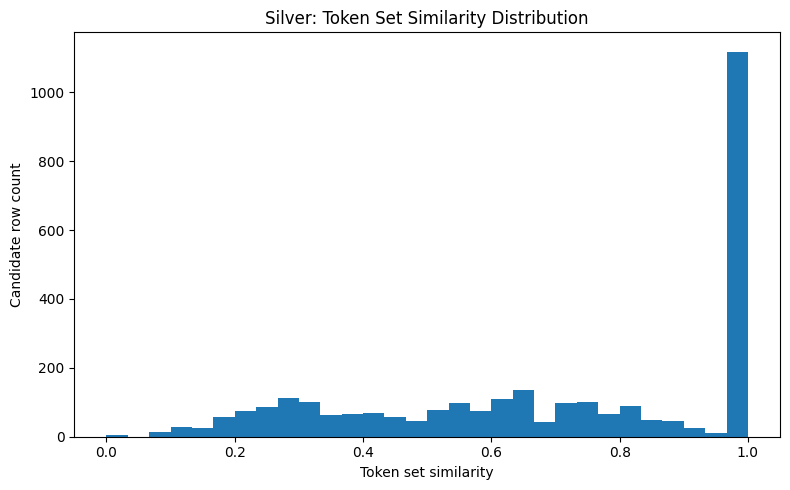

In [20]:

plt.figure(figsize=(8, 5))
plt.hist(silver['token_set_ratio'], bins=30)
plt.xlabel('Token set similarity')
plt.ylabel('Candidate row count')
plt.title('Silver: Token Set Similarity Distribution')
plt.tight_layout()
plt.savefig(FIG_DIR / 'silver_token_set_similarity.png', dpi=150)
plt.show()


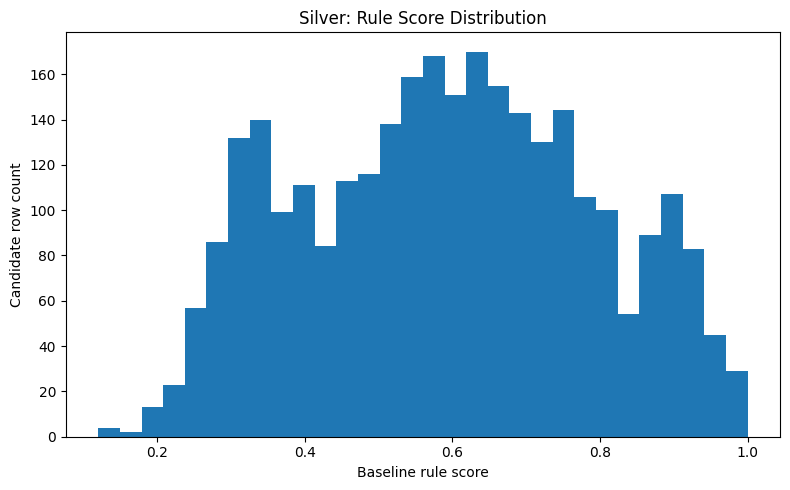

In [21]:

plt.figure(figsize=(8, 5))
plt.hist(silver['baseline_rule_score'], bins=30)
plt.xlabel('Baseline rule score')
plt.ylabel('Candidate row count')
plt.title('Silver: Rule Score Distribution')
plt.tight_layout()
plt.savefig(FIG_DIR / 'silver_rule_score_distribution.png', dpi=150)
plt.show()


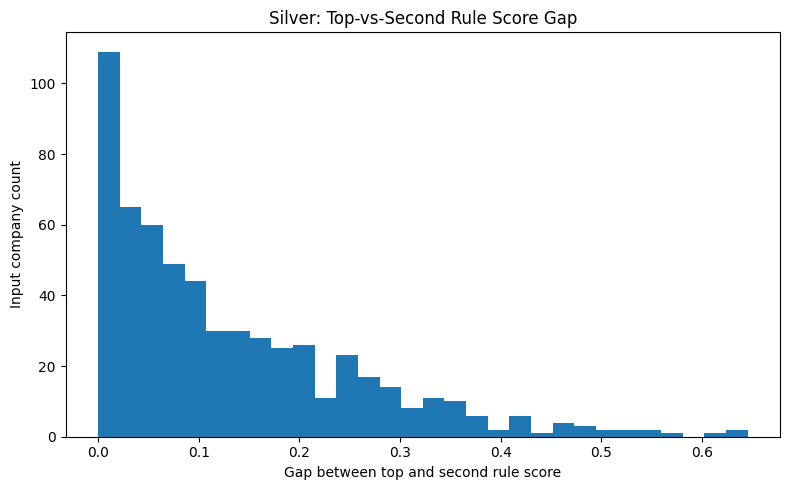

In [22]:

gap_df = silver[['input_row_key','baseline_gap_to_second']].drop_duplicates()
plt.figure(figsize=(8, 5))
plt.hist(gap_df['baseline_gap_to_second'], bins=30)
plt.xlabel('Gap between top and second rule score')
plt.ylabel('Input company count')
plt.title('Silver: Top-vs-Second Rule Score Gap')
plt.tight_layout()
plt.savefig(FIG_DIR / 'silver_score_gap_distribution.png', dpi=150)
plt.show()


## 06. Option 2 — Rule-based entity resolution + QC

In [23]:

# Select the best rule-based candidate per input row.
rule_selected = silver.groupby('input_row_key').head(1).copy()

# First-pass decisioning. These thresholds are intentionally conservative for a supplier-master POC.
rule_selected['confidence_band'] = pd.cut(
    rule_selected['baseline_rule_score'],
    bins=[-np.inf, 0.50, 0.75, 0.90, np.inf],
    labels=['No reliable match', 'Low confidence', 'Medium confidence', 'High confidence']
)

rule_selected['decision'] = np.select(
    [
        rule_selected['baseline_rule_score'] >= 0.90,
        rule_selected['baseline_rule_score'] >= 0.75,
        rule_selected['baseline_rule_score'] < 0.50,
    ],
    ['Auto-match', 'Review match', 'Unmatched / research required'],
    default='Review match'
)

# Conservative gates: downgrade risky auto-matches to review.
rule_selected.loc[(rule_selected['same_country'] == 0) & (rule_selected['decision'] == 'Auto-match'), 'decision'] = 'Review match'
rule_selected.loc[(rule_selected['candidate_has_website'] == 0) & (rule_selected['decision'] == 'Auto-match'), 'decision'] = 'Review match'
rule_selected.loc[(rule_selected['baseline_gap_to_second'] < 0.10) & (rule_selected['decision'] == 'Auto-match'), 'decision'] = 'Review match'

# Reason codes for explainability.
rule_selected['reason_codes'] = rule_selected.apply(lambda r: '; '.join([
    reason for condition, reason in [
        (r['token_set_ratio'] >= 0.85, 'Strong name similarity'),
        (r['exact_normalized_name_match'] == 1, 'Exact normalized name match'),
        (r['same_country'] == 1, 'Country matches'),
        (r['candidate_has_website'] == 1, 'Website present'),
        (r['domain_root_matches_input_token'] == 1, 'Domain aligns with input name'),
        (r['baseline_gap_to_second'] >= 0.20, 'Large gap vs next candidate'),
        (r['same_country'] == 0, 'Country mismatch'),
        (r['candidate_has_website'] == 0, 'Missing website'),
        (r['baseline_gap_to_second'] < 0.10, 'Low separation vs next candidate'),
    ] if condition
]), axis=1)

rule_selected[['input_row_key','input_company_name','company_name','baseline_rule_score','baseline_gap_to_second','decision','confidence_band','reason_codes']].head(10)


,input_row_key,input_company_name,company_name,baseline_rule_score,baseline_gap_to_second,decision,confidence_band,reason_codes
0,0,24-SEVEN MEDIA NETWORK (PRIVATE) LIMITED,New Millennium Network,0.530849,0.005576,Review match,Low confidence,Country matches; Website present; Low separati...
5,1,2OPERATE A/S,2operate,0.877407,0.258144,Review match,Medium confidence,Strong name similarity; Country matches; Websi...
560,2,3 STEP IT A/S,3 Step IT A/S.,0.940000,0.352378,Auto-match,High confidence,Strong name similarity; Exact normalized name ...
1118,3,3 STEP IT AS,3 Step IT A/S.,0.780067,0.078678,Review match,Medium confidence,Strong name similarity; Website present; Count...
1666,4,3 Step IT Sweden AB,Proact IT Sweden,0.668374,0.154622,Review match,Low confidence,Country matches; Website present
2218,5,"3DEGREES GROUP, INC.",3Degrees Inc.,0.836631,0.155943,Review match,Medium confidence,Strong name similarity; Country matches; Websi...
2734,6,3Step IT Group Oy,3Step IT Group,0.960000,0.142812,Auto-match,High confidence,Strong name similarity; Exact normalized name ...
2789,7,A.T. KEARNEY AB,Kearney India,0.637151,0.170463,Review match,Low confidence,Website present; Domain aligns with input name...
2844,8,A. T. KEARNEY PTE. LTD,Kearney,0.762953,0.092286,Review match,Medium confidence,Strong name similarity; Website present; Domai...
2897,9,AALBORG CITY,AALBORG CITY,0.960000,0.093364,Review match,High confidence,Strong name similarity; Exact normalized name ...


In [24]:

# Gold-style resolved entity output from the rule pass.
resolved_rule = rule_selected[[
    'input_row_key','input_company_name','input_main_country_code','input_main_country','input_main_region','input_main_city',
    'company_name','company_legal_names','company_commercial_names','veridion_id','website_url','website_domain','linkedin_url',
    'main_country_code','main_country','main_region','main_city','main_postcode',
    'revenue','revenue_type','employee_count','employee_count_type','main_industry','main_sector',
    'baseline_rule_score','baseline_gap_to_second','decision','confidence_band','reason_codes'
]].copy()

resolved_rule.rename(columns={
    'company_name': 'selected_company_name',
    'company_legal_names': 'selected_company_legal_names',
    'company_commercial_names': 'selected_company_commercial_names',
    'main_country_code': 'selected_country_code',
    'main_country': 'selected_country',
    'main_region': 'selected_region',
    'main_city': 'selected_city',
    'main_postcode': 'selected_postcode',
    'baseline_rule_score': 'self_assessed_confidence_score',
    'baseline_gap_to_second': 'score_gap_to_second',
}, inplace=True)

resolved_rule.head()


,input_row_key,input_company_name,input_main_country_code,input_main_country,input_main_region,input_main_city,selected_company_name,selected_company_legal_names,selected_company_commercial_names,veridion_id,website_url,website_domain,linkedin_url,selected_country_code,selected_country,selected_region,selected_city,selected_postcode,revenue,revenue_type,employee_count,employee_count_type,main_industry,main_sector,self_assessed_confidence_score,score_gap_to_second,decision,confidence_band,reason_codes
0,0,24-SEVEN MEDIA NETWORK (PRIVATE) LIMITED,PK,Pakistan,Sindh,Karachi,New Millennium Network,New Millennium Network Private Limited | MNET ...,New Millennium Network,26e22210-93e5-11eb-b997-8dd98d09cf25,https://www.mnet.com.pk/,mnet.com.pk,http://www.linkedin.com/company/mnet-services-...,PK,Pakistan,Sindh,Karachi,74400,311793.0,modelled,23.0,extracted,Telecommunication Services,IT&C Services,0.530849,0.005576,Review match,Low confidence,Country matches; Website present; Low separati...
5,1,2OPERATE A/S,DK,Denmark,North Denmark Region,Aalborg,2operate,2operate A/S.,2operate,8b99ef83-93e4-11eb-b997-8dd98d09cf25,https://www.2operate.com/,2operate.com,https://www.linkedin.com/company/2operate-as,DK,Denmark,North Denmark Region,Aalborg Municipality,9220,28698964.0,modelled,75.0,modelled,Telecommunication Services,IT&C Services,0.877407,0.258144,Review match,Medium confidence,Strong name similarity; Country matches; Websi...
560,2,3 STEP IT A/S,DK,Denmark,Region Of Southern Denmark,Tønder Municipality,3 Step IT A/S.,3 Step IT A/S.,NaN,45309031-f8ab-11ed-89fe-613148a94f23,http://www.3stepit.dk/?opi=79508299&sa=U&ved=0...,3stepit.dk,NaN,DK,Denmark,Capital Region Of Denmark,Gladsaxe Municipality,2860,NaN,NaN,NaN,NaN,Banks & Financial Services,Finance & Insurance,0.940000,0.352378,Auto-match,High confidence,Strong name similarity; Exact normalized name ...
1118,3,3 STEP IT AS,NO,Norway,Oslo,Oslo,3 Step IT A/S.,3 Step IT A/S.,NaN,45309031-f8ab-11ed-89fe-613148a94f23,http://www.3stepit.dk/?opi=79508299&sa=U&ved=0...,3stepit.dk,NaN,DK,Denmark,Capital Region Of Denmark,Gladsaxe Municipality,2860,NaN,NaN,NaN,NaN,Banks & Financial Services,Finance & Insurance,0.780067,0.078678,Review match,Medium confidence,Strong name similarity; Website present; Count...
1666,4,3 Step IT Sweden AB,SE,Sweden,Östergötland County,Linköping,Proact IT Sweden,Proact IT Sweden AB. | Proact Systems A/S. | P...,Proact IT Sweden,e5cede70-0409-11ed-a83d-25d09483d16d,http://www.proact.se/,proact.se,http://www.linkedin.com/company/proact-it-swed...,SE,Sweden,Västra Götaland County,Gothenburg,41263,7000000.0,extracted,130.0,extracted,Telecommunication Services,IT&C Services,0.668374,0.154622,Review match,Low confidence,Country matches; Website present


In [25]:

# Generate QC issue backlog from the rule-selected match.
qc_records = []
for _, row in rule_selected.iterrows():
    base = {
        'input_row_key': row['input_row_key'],
        'input_company_name': row['input_company_name'],
        'selected_company_name': row['company_name'],
        'decision': row['decision'],
        'confidence_band': row['confidence_band'],
        'self_assessed_confidence_score': row['baseline_rule_score'],
        'source_url': row.get('website_url', ''),
    }
    checks = [
        (row['same_country'] == 0, 'Country mismatch', 'Medium', 'Validate whether the candidate is a parent/HQ entity or a wrong-country match.'),
        (row['candidate_has_website'] == 0, 'Missing website', 'Medium', 'Research the entity website or verify via external sources.'),
        (row['baseline_gap_to_second'] < 0.10, 'Ambiguous top match', 'High', 'Review top candidates manually; the top score is not sufficiently separated.'),
        (row['baseline_rule_score'] < 0.50, 'No reliable match', 'High', 'Research externally or leave unmatched until stronger evidence is available.'),
        (row['has_revenue'] == 0, 'Missing revenue attribute', 'Low', 'Backfill revenue if needed for supplier segmentation.'),
        (row['has_employee_count'] == 0, 'Missing employee attribute', 'Low', 'Backfill employee count if needed for supplier profiling.'),
    ]
    for condition, issue_type, severity, action in checks:
        if condition:
            record = base.copy()
            record.update({'issue_type': issue_type, 'severity': severity, 'recommended_action': action})
            qc_records.append(record)

qc_issues_rule = pd.DataFrame(qc_records)
qc_issues_rule.head(10)


,input_row_key,input_company_name,selected_company_name,decision,confidence_band,self_assessed_confidence_score,source_url,issue_type,severity,recommended_action
0,0,24-SEVEN MEDIA NETWORK (PRIVATE) LIMITED,New Millennium Network,Review match,Low confidence,0.530849,https://www.mnet.com.pk/,Ambiguous top match,High,Review top candidates manually; the top score ...
1,2,3 STEP IT A/S,3 Step IT A/S.,Auto-match,High confidence,0.940000,http://www.3stepit.dk/?opi=79508299&sa=U&ved=0...,Missing revenue attribute,Low,Backfill revenue if needed for supplier segmen...
2,2,3 STEP IT A/S,3 Step IT A/S.,Auto-match,High confidence,0.940000,http://www.3stepit.dk/?opi=79508299&sa=U&ved=0...,Missing employee attribute,Low,Backfill employee count if needed for supplier...
3,3,3 STEP IT AS,3 Step IT A/S.,Review match,Medium confidence,0.780067,http://www.3stepit.dk/?opi=79508299&sa=U&ved=0...,Country mismatch,Medium,Validate whether the candidate is a parent/HQ ...
4,3,3 STEP IT AS,3 Step IT A/S.,Review match,Medium confidence,0.780067,http://www.3stepit.dk/?opi=79508299&sa=U&ved=0...,Ambiguous top match,High,Review top candidates manually; the top score ...
5,3,3 STEP IT AS,3 Step IT A/S.,Review match,Medium confidence,0.780067,http://www.3stepit.dk/?opi=79508299&sa=U&ved=0...,Missing revenue attribute,Low,Backfill revenue if needed for supplier segmen...
6,3,3 STEP IT AS,3 Step IT A/S.,Review match,Medium confidence,0.780067,http://www.3stepit.dk/?opi=79508299&sa=U&ved=0...,Missing employee attribute,Low,Backfill employee count if needed for supplier...
7,5,"3DEGREES GROUP, INC.",3Degrees Inc.,Review match,Medium confidence,0.836631,http://3degreesinc.com/,Missing revenue attribute,Low,Backfill revenue if needed for supplier segmen...
8,5,"3DEGREES GROUP, INC.",3Degrees Inc.,Review match,Medium confidence,0.836631,http://3degreesinc.com/,Missing employee attribute,Low,Backfill employee count if needed for supplier...
9,7,A.T. KEARNEY AB,Kearney India,Review match,Low confidence,0.637151,https://www.kearney.in/,Country mismatch,Medium,Validate whether the candidate is a parent/HQ ...


In [26]:

# Review queue from rule pass
review_queue_rule = rule_selected[rule_selected['decision'] != 'Auto-match'].copy()
review_queue_rule['priority_score'] = (
    (1 - review_queue_rule['baseline_rule_score']) * 50 +
    (review_queue_rule['baseline_gap_to_second'] < 0.10).astype(int) * 20 +
    (review_queue_rule['same_country'] == 0).astype(int) * 15 +
    (review_queue_rule['candidate_has_website'] == 0).astype(int) * 10 +
    review_queue_rule['hard_negative_flag'].astype(int) * 5
)
review_queue_rule['priority_band'] = pd.cut(review_queue_rule['priority_score'], bins=[-np.inf, 20, 40, np.inf], labels=['Low', 'Medium', 'High'])
review_queue_rule = review_queue_rule.sort_values(['priority_score','baseline_rule_score'], ascending=[False, True])
review_queue_rule[['input_row_key','input_company_name','company_name','decision','baseline_rule_score','priority_score','priority_band']].head(10)


,input_row_key,input_company_name,company_name,decision,baseline_rule_score,priority_score,priority_band
1286,33,"American Express Europe Denmark, filial af Ame...",American Express Corp.,Review match,0.524032,73.798405,High
1364,343,NEC Scandinavia Aktiebolag,NEC Scandinavia AB.,Review match,0.696027,65.198656,High
106,117,DADES Center Ost ApS,Dades Center,Review match,0.698724,65.063816,High
1464,362,DMA Research A/S,DMA Analytics,Unmatched / research required,0.438529,63.073561,High
1494,368,ITELLIGENCE A/S,ITELLIGENCE,Review match,0.750669,62.466542,High
2002,460,Skillpower Services (Thailand) Co Ltd,ALE -Heavylift and Transport Thailand Co Ltd.,Unmatched / research required,0.455860,62.207014,High
1961,453,Siae Microelettronica Sdn. Bhd.,Siae Microelettronica Co.ltd,Review match,0.769164,61.541824,High
115,119,DAILY JURRAT,Daily Jurr'at,Review match,0.695292,60.235403,High
2340,520,Telenor Magyarorszag Zrt.,Telenor mobil antenna,Unmatched / research required,0.458507,57.074671,High
1346,340,NAGARRO ENTERPRISE SERVICES PRIVATE LIMITED,Enterprise Information Services LLC EIS,Review match,0.563929,56.803569,High


## 07. Export first-pass resolved/QC output and use it as label source

In [27]:

# Create the first-pass resolved workbook. This becomes the label source for the predictive model.
rule_output_path = EXPORT_DIR / '01_rule_based_resolved_qc_output.xlsx'

business_metrics_rule = pd.DataFrame([
    {'metric': 'Total input entities', 'value': resolved_rule['input_row_key'].nunique()},
    {'metric': 'Total candidate rows', 'value': len(silver)},
    {'metric': 'Auto-match count', 'value': int((resolved_rule['decision'] == 'Auto-match').sum())},
    {'metric': 'Review match count', 'value': int((resolved_rule['decision'] == 'Review match').sum())},
    {'metric': 'Unmatched / research required count', 'value': int((resolved_rule['decision'] == 'Unmatched / research required').sum())},
    {'metric': 'QC issue count', 'value': int(len(qc_issues_rule))},
    {'metric': 'Review queue count', 'value': int(len(review_queue_rule))},
])

with pd.ExcelWriter(rule_output_path, engine='xlsxwriter') as writer:
    resolved_rule.to_excel(writer, sheet_name='Gold_Resolved_Entities', index=False)
    silver.to_excel(writer, sheet_name='Silver_Candidate_Scoring', index=False)
    qc_issues_rule.to_excel(writer, sheet_name='Gold_QC_Issues', index=False)
    review_queue_rule.to_excel(writer, sheet_name='Gold_Review_Queue', index=False)
    business_metrics_rule.to_excel(writer, sheet_name='Gold_Business_Metrics', index=False)
    bronze_profile.to_excel(writer, sheet_name='Bronze_Profile', index=False)

print('Created first-pass resolved/QC workbook:', rule_output_path)
business_metrics_rule


Created first-pass resolved/QC workbook: C:\Users\pauls\Downloads\data_analyst\entity_resolution_raw_to_ml\exports\01_rule_based_resolved_qc_output.xlsx


,metric,value
0,Total input entities,592
1,Total candidate rows,2951
2,Auto-match count,72
3,Review match count,507
4,Unmatched / research required count,13
5,QC issue count,1117
6,Review queue count,520


In [28]:

# Create labels from the generated rule-based resolved output.
# Rule-selected Auto-match and Review match rows become positive labels.
# Unmatched/research-required rows get no positive candidate; all candidates are labeled 0.
label_source = resolved_rule[['input_row_key','veridion_id','decision']].copy()
label_source['veridion_id'] = label_source['veridion_id'].astype(str)
label_source['selected_positive_label'] = (~label_source['decision'].eq('Unmatched / research required')).astype(int)

silver['veridion_id_str'] = silver['veridion_id'].astype(str)
silver = silver.merge(
    label_source[['input_row_key','veridion_id','selected_positive_label']],
    how='left',
    left_on=['input_row_key','veridion_id_str'],
    right_on=['input_row_key','veridion_id']
)
silver.drop(columns=['veridion_id_y'], inplace=True, errors='ignore')
silver.rename(columns={'veridion_id_x':'veridion_id'}, inplace=True)
silver['label'] = silver['selected_positive_label'].fillna(0).astype(int)
silver['label_source'] = 'generated_from_rule_based_resolution'

print('Labeled rows:', silver['label'].notna().sum())
print('Positive labels:', int(silver['label'].sum()))
print('Inputs with positive selected match:', silver.loc[silver['label'] == 1, 'input_row_key'].nunique())
silver[['input_row_key','company_name','baseline_rank','decision' if 'decision' in silver.columns else 'baseline_rank','label']].head()


Labeled rows: 2951
Positive labels: 579
Inputs with positive selected match: 579


,input_row_key,company_name,baseline_rank,baseline_rank,label
0,0,New Millennium Network,1,1,1
1,0,24seven Research Network,2,2,0
2,0,Asiatic Public Relations Network,3,3,0
3,0,Private Helipad Ali Villa,4,4,0
4,0,EmerioSoft,5,5,0


## 08. Option 1 — Predictive model using generated labels

In [29]:

feature_cols = [
    'name_ratio','partial_ratio','token_sort_ratio','token_set_ratio','variant_ratio',
    'exact_normalized_name_match','token_overlap_ratio','weighted_token_overlap','rare_token_match_count',
    'candidate_has_website','candidate_has_linkedin','domain_root_matches_input_token',
    'same_country','same_city','same_postcode',
    'has_revenue','has_employee_count','has_year_founded','has_description','has_industry','has_phone','has_email',
    'candidate_count_for_input','engine_is_top1','pre_context_score','pre_context_rank','pre_context_gap_to_best',
    'baseline_rule_score','baseline_rank','baseline_gap_to_second','hard_negative_flag'
]

model_df = silver[silver['label'].notna()].copy()
model_df['label'] = model_df['label'].astype(int)

print('Training rows:', len(model_df))
print('Training groups:', model_df['input_row_key'].nunique())
print('Positive rate:', round(model_df['label'].mean(), 4))


Training rows: 2951
Training groups: 592
Positive rate: 0.1962


In [30]:

# Group-based train/test split prevents leakage across candidates for the same input company.
splitter = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=42)
train_idx, test_idx = next(splitter.split(model_df[feature_cols], model_df['label'], groups=model_df['input_row_key']))

train_df = model_df.iloc[train_idx].copy()
test_df = model_df.iloc[test_idx].copy()

X_train = train_df[feature_cols]
y_train = train_df['label']
X_test = test_df[feature_cols]
y_test = test_df['label']

print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)


Train shape: (2219, 133)
Test shape: (732, 133)


In [31]:

base_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42))
])

base_pipeline.fit(X_train, y_train)
calibration_method = 'isotonic' if y_train.sum() >= 50 else 'sigmoid'
try:
    calibrated_model = CalibratedClassifierCV(estimator=base_pipeline, method=calibration_method, cv=3)
except TypeError:
    calibrated_model = CalibratedClassifierCV(base_estimator=base_pipeline, method=calibration_method, cv=3)

calibrated_model.fit(X_train, y_train)
joblib.dump(calibrated_model, MODEL_DIR / 'calibrated_logistic_model_from_generated_labels.joblib')
print('Calibration method:', calibration_method)


Calibration method: isotonic


## 09. Model validation and overfitting controls

In [32]:

test_df['pred_proba'] = calibrated_model.predict_proba(X_test)[:, 1]
test_df['pred_label_050'] = (test_df['pred_proba'] >= 0.50).astype(int)

print('Average precision:', round(average_precision_score(y_test, test_df['pred_proba']), 4))
print(classification_report(y_test, test_df['pred_label_050'], digits=4))

# Group-level top-1 accuracy: did the model pick the generated selected candidate?
test_top1 = test_df.sort_values(['input_row_key','pred_proba'], ascending=[True, False]).groupby('input_row_key').head(1).copy()
model_top1_accuracy = test_top1['label'].mean()
print('Model top-1 accuracy against generated labels:', round(float(model_top1_accuracy), 4))


Average precision: 0.9996
              precision    recall  f1-score   support

           0     0.9966    0.9966    0.9966       589
           1     0.9860    0.9860    0.9860       143

    accuracy                         0.9945       732
   macro avg     0.9913    0.9913    0.9913       732
weighted avg     0.9945    0.9945    0.9945       732

Model top-1 accuracy against generated labels: 0.9662


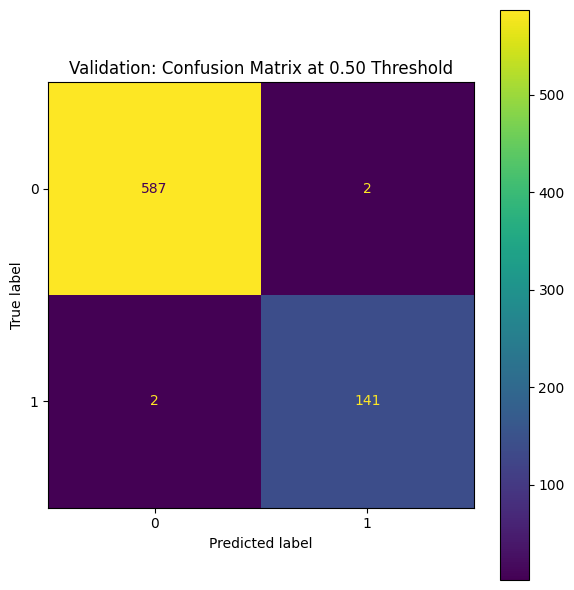

In [33]:

plt.figure(figsize=(6, 6))
cm = confusion_matrix(y_test, test_df['pred_label_050'])
ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=plt.gca())
plt.title('Validation: Confusion Matrix at 0.50 Threshold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'validation_confusion_matrix.png', dpi=150)
plt.show()


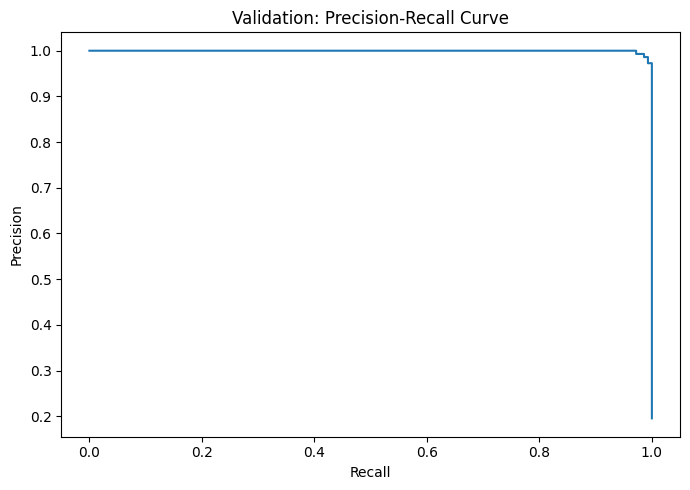

In [34]:

precision, recall, _ = precision_recall_curve(y_test, test_df['pred_proba'])
plt.figure(figsize=(7, 5))
plt.plot(recall, precision)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Validation: Precision-Recall Curve')
plt.tight_layout()
plt.savefig(FIG_DIR / 'validation_precision_recall_curve.png', dpi=150)
plt.show()


In [35]:

# GroupKFold cross-validation
cv = GroupKFold(n_splits=3)
cv_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42))
])
cv_results = cross_validate(
    cv_pipeline,
    model_df[feature_cols],
    model_df['label'],
    groups=model_df['input_row_key'],
    cv=cv,
    scoring={'average_precision':'average_precision','roc_auc':'roc_auc','f1':'f1','precision':'precision','recall':'recall'},
    return_train_score=True,
)
cv_summary = pd.DataFrame({
    'metric': ['average_precision','roc_auc','f1','precision','recall'],
    'train_mean': [cv_results[f'train_{m}'].mean() for m in ['average_precision','roc_auc','f1','precision','recall']],
    'train_std': [cv_results[f'train_{m}'].std() for m in ['average_precision','roc_auc','f1','precision','recall']],
    'validation_mean': [cv_results[f'test_{m}'].mean() for m in ['average_precision','roc_auc','f1','precision','recall']],
    'validation_std': [cv_results[f'test_{m}'].std() for m in ['average_precision','roc_auc','f1','precision','recall']],
})
cv_summary


,metric,train_mean,train_std,validation_mean,validation_std
0,average_precision,0.999971,0.000009,0.999793,0.000068
1,roc_auc,0.999993,0.000002,0.999950,0.000016
2,f1,0.991439,0.000601,0.989739,0.002115
3,precision,0.983023,0.001182,0.979695,0.004145
4,recall,1.000000,0.000000,1.000000,0.000000


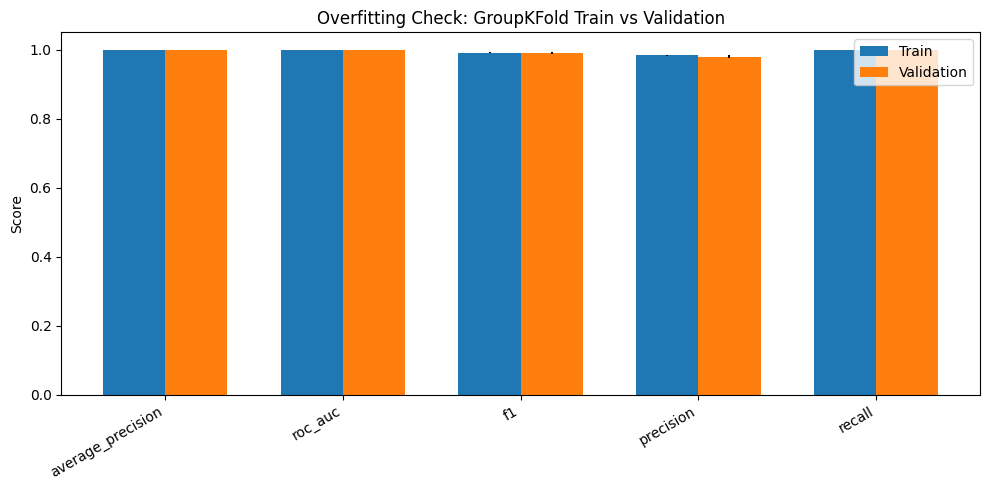

In [36]:

plt.figure(figsize=(10, 5))
x = np.arange(len(cv_summary))
width = 0.35
plt.bar(x - width/2, cv_summary['train_mean'], width, yerr=cv_summary['train_std'], label='Train')
plt.bar(x + width/2, cv_summary['validation_mean'], width, yerr=cv_summary['validation_std'], label='Validation')
plt.xticks(x, cv_summary['metric'], rotation=30, ha='right')
plt.ylabel('Score')
plt.title('Overfitting Check: GroupKFold Train vs Validation')
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'overfitting_groupkfold_train_vs_validation.png', dpi=150)
plt.show()


In [37]:

# Regularization tuning
param_grid = {'model__C': [0.01, 0.03, 0.1, 0.3, 1.0], 'model__penalty': ['l2']}
grid = GridSearchCV(cv_pipeline, param_grid=param_grid, scoring='average_precision', cv=cv, return_train_score=True)
grid.fit(model_df[feature_cols], model_df['label'], groups=model_df['input_row_key'])
regularization_results = pd.DataFrame(grid.cv_results_)[[
    'param_model__C','mean_train_score','std_train_score','mean_test_score','std_test_score','rank_test_score'
]].sort_values('rank_test_score')
print('Best parameters:', grid.best_params_)
print('Best GroupKFold average precision:', round(grid.best_score_, 4))
regularization_results


Best parameters: {'model__C': 1.0, 'model__penalty': 'l2'}
Best GroupKFold average precision: 0.9998


,param_model__C,mean_train_score,std_train_score,mean_test_score,std_test_score,rank_test_score
4,1.00,0.999971,0.000009,0.999793,0.000068,1
3,0.30,0.999711,0.000041,0.999421,0.000296,2
2,0.10,0.999092,0.000102,0.998419,0.000239,3
1,0.03,0.993182,0.000283,0.991835,0.002455,4
0,0.01,0.973069,0.001875,0.970493,0.008542,5


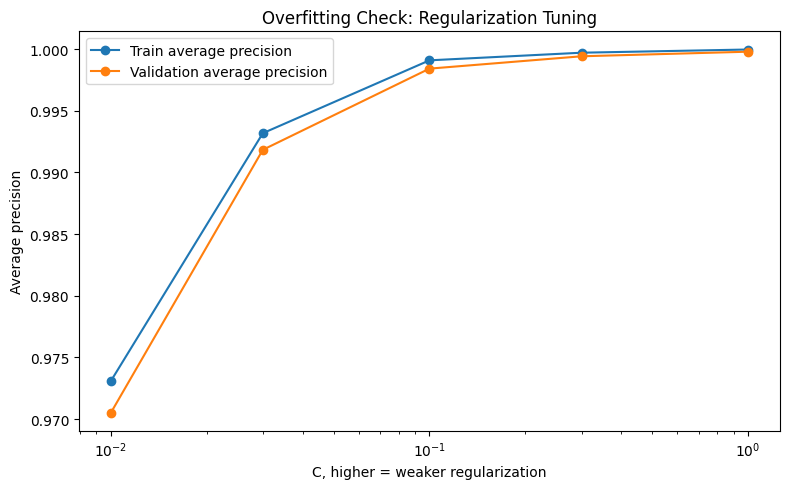

In [38]:

reg_plot = regularization_results.sort_values('param_model__C')
plt.figure(figsize=(8, 5))
plt.plot(reg_plot['param_model__C'].astype(float), reg_plot['mean_train_score'], marker='o', label='Train average precision')
plt.plot(reg_plot['param_model__C'].astype(float), reg_plot['mean_test_score'], marker='o', label='Validation average precision')
plt.xscale('log')
plt.xlabel('C, higher = weaker regularization')
plt.ylabel('Average precision')
plt.title('Overfitting Check: Regularization Tuning')
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'overfitting_regularization_tuning.png', dpi=150)
plt.show()


In [39]:

# Baseline-feature ablation
baseline_feature_cols = ['baseline_rule_score','baseline_rank','baseline_gap_to_second','pre_context_score','pre_context_rank','pre_context_gap_to_best']
feature_cols_without_baseline = [c for c in feature_cols if c not in baseline_feature_cols]

def run_group_cv(cols, name):
    pipe = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42))
    ])
    res = cross_validate(pipe, model_df[cols], model_df['label'], groups=model_df['input_row_key'], cv=cv,
                         scoring={'average_precision':'average_precision','roc_auc':'roc_auc','f1':'f1'}, return_train_score=True)
    return {
        'feature_set': name,
        'n_features': len(cols),
        'train_avg_precision': res['train_average_precision'].mean(),
        'validation_avg_precision': res['test_average_precision'].mean(),
        'validation_avg_precision_std': res['test_average_precision'].std(),
        'train_roc_auc': res['train_roc_auc'].mean(),
        'validation_roc_auc': res['test_roc_auc'].mean(),
        'train_f1': res['train_f1'].mean(),
        'validation_f1': res['test_f1'].mean(),
    }

ablation_results = pd.DataFrame([
    run_group_cv(feature_cols_without_baseline, 'No baseline/ranking features'),
    run_group_cv(feature_cols, 'All features including baseline/ranking'),
])
ablation_results


,feature_set,n_features,train_avg_precision,validation_avg_precision,validation_avg_precision_std,train_roc_auc,validation_roc_auc,train_f1,validation_f1
0,No baseline/ranking features,25,0.722909,0.707377,0.023845,0.911440,0.903193,0.633163,0.620867
1,All features including baseline/ranking,31,0.999971,0.999793,0.000068,0.999993,0.999950,0.991439,0.989739


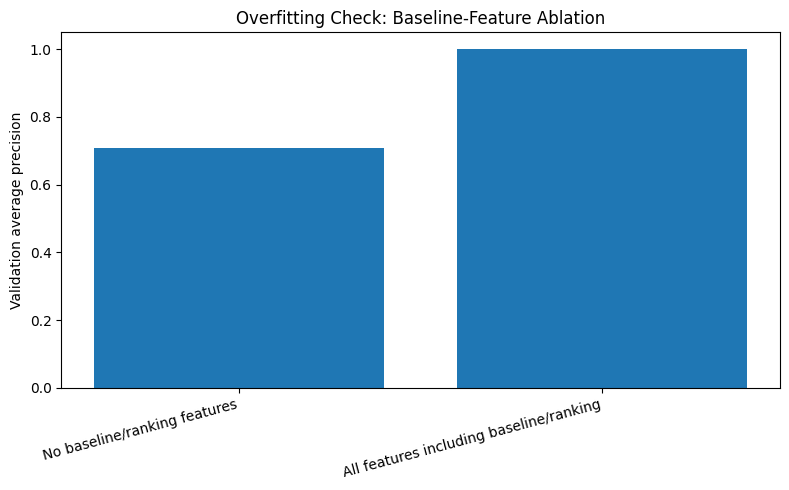

In [40]:

plt.figure(figsize=(8, 5))
plt.bar(ablation_results['feature_set'], ablation_results['validation_avg_precision'])
plt.ylabel('Validation average precision')
plt.title('Overfitting Check: Baseline-Feature Ablation')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig(FIG_DIR / 'overfitting_baseline_feature_ablation.png', dpi=150)
plt.show()


In [41]:

# Learning curve
learning_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42, C=grid.best_params_.get('model__C', 1.0)))
])
train_sizes, train_scores, validation_scores = learning_curve(
    learning_pipeline,
    model_df[feature_cols],
    model_df['label'],
    groups=model_df['input_row_key'],
    cv=cv,
    scoring='average_precision',
    train_sizes=np.linspace(0.3, 1.0, 3),
)
learning_curve_df = pd.DataFrame({
    'train_size': train_sizes,
    'train_mean_average_precision': train_scores.mean(axis=1),
    'train_std_average_precision': train_scores.std(axis=1),
    'validation_mean_average_precision': validation_scores.mean(axis=1),
    'validation_std_average_precision': validation_scores.std(axis=1),
})
learning_curve_df


,train_size,train_mean_average_precision,train_std_average_precision,validation_mean_average_precision,validation_std_average_precision
0,590,1.000000,0.000000,0.997440,0.001448
1,1278,0.999848,0.000162,0.999430,0.000145
2,1967,0.999971,0.000009,0.999793,0.000068


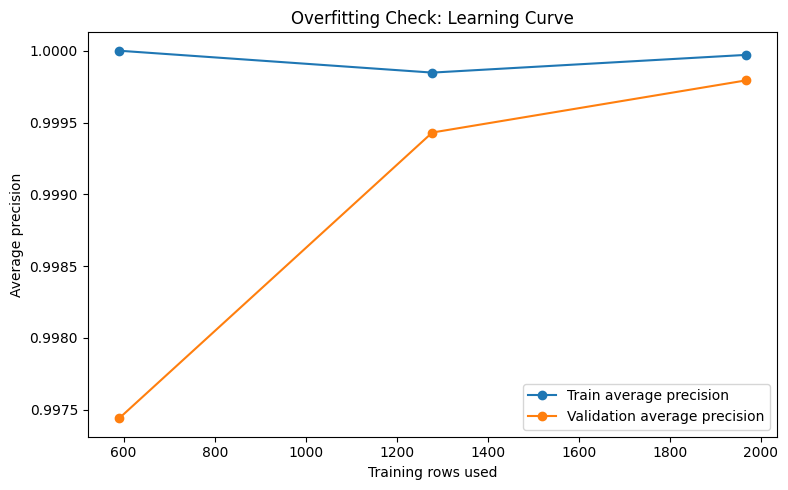

In [42]:

plt.figure(figsize=(8, 5))
plt.plot(learning_curve_df['train_size'], learning_curve_df['train_mean_average_precision'], marker='o', label='Train average precision')
plt.plot(learning_curve_df['train_size'], learning_curve_df['validation_mean_average_precision'], marker='o', label='Validation average precision')
plt.xlabel('Training rows used')
plt.ylabel('Average precision')
plt.title('Overfitting Check: Learning Curve')
plt.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'overfitting_learning_curve.png', dpi=150)
plt.show()


## 10. Gold — ML-scored resolution output

In [43]:

# Train final calibrated model on all generated labels and score all candidates.
final_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=3000, class_weight='balanced', random_state=42, C=grid.best_params_.get('model__C', 1.0)))
])
final_pipeline.fit(model_df[feature_cols], model_df['label'])
try:
    final_calibrated_model = CalibratedClassifierCV(estimator=final_pipeline, method=calibration_method, cv=3)
except TypeError:
    final_calibrated_model = CalibratedClassifierCV(base_estimator=final_pipeline, method=calibration_method, cv=3)
final_calibrated_model.fit(model_df[feature_cols], model_df['label'])

silver['predicted_match_probability'] = final_calibrated_model.predict_proba(silver[feature_cols])[:, 1]
silver = silver.sort_values(['input_row_key','predicted_match_probability'], ascending=[True, False]).copy()
silver['predicted_rank'] = silver.groupby('input_row_key').cumcount() + 1
silver['top_predicted_probability'] = silver.groupby('input_row_key')['predicted_match_probability'].transform('max')
silver['second_predicted_probability'] = silver.groupby('input_row_key')['predicted_match_probability'].transform(lambda s: s.nlargest(2).iloc[-1] if len(s) > 1 else np.nan)
silver['predicted_gap_to_second'] = (silver['top_predicted_probability'] - silver['second_predicted_probability']).fillna(silver['top_predicted_probability'])

ml_selected = silver.groupby('input_row_key').head(1).copy()
ml_selected['confidence_band'] = pd.cut(ml_selected['predicted_match_probability'], bins=[-np.inf, 0.50, 0.75, 0.90, np.inf], labels=['No reliable match','Low confidence','Medium confidence','High confidence'])
ml_selected['decision'] = np.select([
    ml_selected['predicted_match_probability'] >= 0.90,
    ml_selected['predicted_match_probability'] >= 0.75,
    ml_selected['predicted_match_probability'] < 0.50,
], ['Auto-match','Review match','Unmatched / research required'], default='Review match')

# Conservative QC gates remain active.
ml_selected.loc[(ml_selected['same_country'] == 0) & (ml_selected['decision'] == 'Auto-match'), 'decision'] = 'Review match'
ml_selected.loc[(ml_selected['candidate_has_website'] == 0) & (ml_selected['decision'] == 'Auto-match'), 'decision'] = 'Review match'
ml_selected.loc[(ml_selected['predicted_gap_to_second'] < 0.10) & (ml_selected['decision'] == 'Auto-match'), 'decision'] = 'Review match'

ml_selected['reason_codes'] = ml_selected.apply(lambda r: '; '.join([
    reason for condition, reason in [
        (r['token_set_ratio'] >= 0.85, 'Strong name similarity'),
        (r['exact_normalized_name_match'] == 1, 'Exact normalized name match'),
        (r['same_country'] == 1, 'Country matches'),
        (r['candidate_has_website'] == 1, 'Website present'),
        (r['domain_root_matches_input_token'] == 1, 'Domain aligns with input name'),
        (r['predicted_gap_to_second'] >= 0.20, 'Large gap vs next candidate'),
        (r['same_country'] == 0, 'Country mismatch'),
        (r['candidate_has_website'] == 0, 'Missing website'),
        (r['predicted_gap_to_second'] < 0.10, 'Low separation vs next candidate'),
    ] if condition
]), axis=1)

ml_resolved = ml_selected[[
    'input_row_key','input_company_name','input_main_country_code','input_main_country','input_main_region','input_main_city',
    'company_name','company_legal_names','company_commercial_names','veridion_id','website_url','website_domain','linkedin_url',
    'main_country_code','main_country','main_region','main_city','main_postcode',
    'revenue','revenue_type','employee_count','employee_count_type','main_industry','main_sector',
    'predicted_match_probability','predicted_gap_to_second','decision','confidence_band','reason_codes'
]].copy()
ml_resolved.rename(columns={
    'company_name':'selected_company_name',
    'company_legal_names':'selected_company_legal_names',
    'company_commercial_names':'selected_company_commercial_names',
    'main_country_code':'selected_country_code',
    'main_country':'selected_country',
    'main_region':'selected_region',
    'main_city':'selected_city',
    'main_postcode':'selected_postcode',
    'predicted_match_probability':'self_assessed_confidence_score',
    'predicted_gap_to_second':'score_gap_to_second',
}, inplace=True)

ml_resolved.head()


,input_row_key,input_company_name,input_main_country_code,input_main_country,input_main_region,input_main_city,selected_company_name,selected_company_legal_names,selected_company_commercial_names,veridion_id,website_url,website_domain,linkedin_url,selected_country_code,selected_country,selected_region,selected_city,selected_postcode,revenue,revenue_type,employee_count,employee_count_type,main_industry,main_sector,self_assessed_confidence_score,score_gap_to_second,decision,confidence_band,reason_codes
0,0,24-SEVEN MEDIA NETWORK (PRIVATE) LIMITED,PK,Pakistan,Sindh,Karachi,New Millennium Network,New Millennium Network Private Limited | MNET ...,New Millennium Network,26e22210-93e5-11eb-b997-8dd98d09cf25,https://www.mnet.com.pk/,mnet.com.pk,http://www.linkedin.com/company/mnet-services-...,PK,Pakistan,Sindh,Karachi,74400,311793.0,modelled,23.0,extracted,Telecommunication Services,IT&C Services,0.939394,0.939394,Auto-match,High confidence,Country matches; Website present; Large gap vs...
5,1,2OPERATE A/S,DK,Denmark,North Denmark Region,Aalborg,2operate,2operate A/S.,2operate,8b99ef83-93e4-11eb-b997-8dd98d09cf25,https://www.2operate.com/,2operate.com,https://www.linkedin.com/company/2operate-as,DK,Denmark,North Denmark Region,Aalborg Municipality,9220,28698964.0,modelled,75.0,modelled,Telecommunication Services,IT&C Services,1.000000,1.000000,Auto-match,High confidence,Strong name similarity; Country matches; Websi...
10,2,3 STEP IT A/S,DK,Denmark,Region Of Southern Denmark,Tønder Municipality,3 Step IT A/S.,3 Step IT A/S.,NaN,45309031-f8ab-11ed-89fe-613148a94f23,http://www.3stepit.dk/?opi=79508299&sa=U&ved=0...,3stepit.dk,NaN,DK,Denmark,Capital Region Of Denmark,Gladsaxe Municipality,2860,NaN,NaN,NaN,NaN,Banks & Financial Services,Finance & Insurance,1.000000,1.000000,Auto-match,High confidence,Strong name similarity; Exact normalized name ...
15,3,3 STEP IT AS,NO,Norway,Oslo,Oslo,3 Step IT A/S.,3 Step IT A/S.,NaN,45309031-f8ab-11ed-89fe-613148a94f23,http://www.3stepit.dk/?opi=79508299&sa=U&ved=0...,3stepit.dk,NaN,DK,Denmark,Capital Region Of Denmark,Gladsaxe Municipality,2860,NaN,NaN,NaN,NaN,Banks & Financial Services,Finance & Insurance,1.000000,1.000000,Review match,High confidence,Strong name similarity; Website present; Large...
20,4,3 Step IT Sweden AB,SE,Sweden,Östergötland County,Linköping,Proact IT Sweden,Proact IT Sweden AB. | Proact Systems A/S. | P...,Proact IT Sweden,e5cede70-0409-11ed-a83d-25d09483d16d,http://www.proact.se/,proact.se,http://www.linkedin.com/company/proact-it-swed...,SE,Sweden,Västra Götaland County,Gothenburg,41263,7000000.0,extracted,130.0,extracted,Telecommunication Services,IT&C Services,1.000000,1.000000,Auto-match,High confidence,Country matches; Website present; Large gap vs...


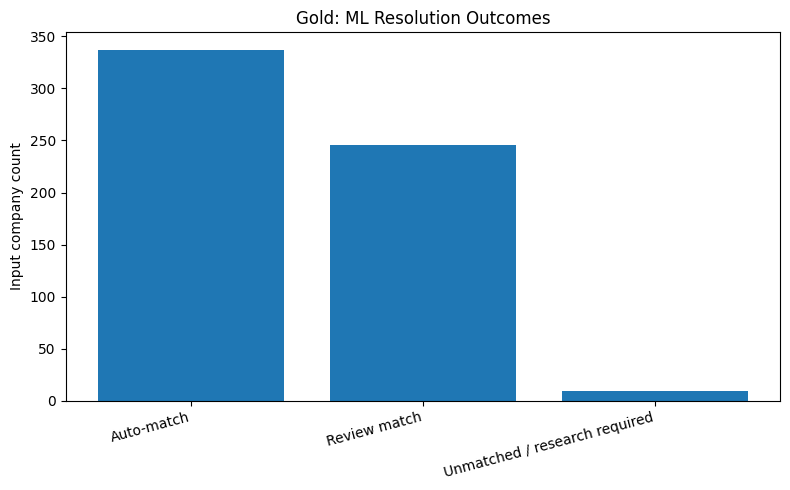

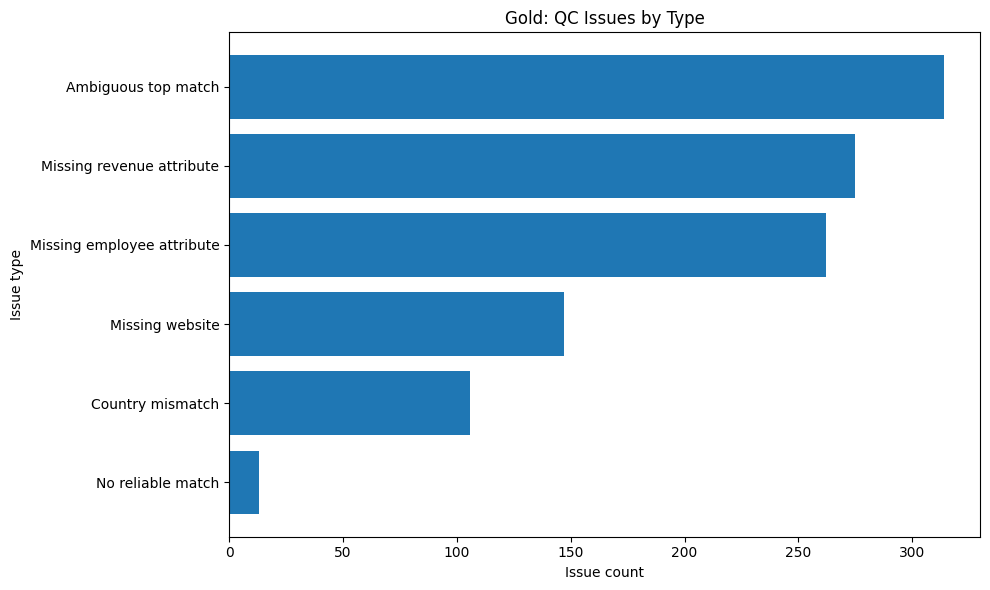

In [44]:

# Final Gold visualizations
plt.figure(figsize=(8, 5))
counts = ml_resolved['decision'].value_counts()
plt.bar(counts.index, counts.values)
plt.xticks(rotation=15, ha='right')
plt.ylabel('Input company count')
plt.title('Gold: ML Resolution Outcomes')
plt.tight_layout()
plt.savefig(FIG_DIR / 'gold_ml_resolution_outcomes.png', dpi=150)
plt.show()

if not qc_issues_rule.empty:
    qc_counts = qc_issues_rule['issue_type'].value_counts().head(15)
    plt.figure(figsize=(10, 6))
    plt.barh(qc_counts.index[::-1], qc_counts.values[::-1])
    plt.xlabel('Issue count')
    plt.ylabel('Issue type')
    plt.title('Gold: QC Issues by Type')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'gold_qc_issues_by_type.png', dpi=150)
    plt.show()


## 11. Export final ML output and validation artifacts

In [47]:

final_output_path = EXPORT_DIR /'output'/'02_ml_scored_resolved_qc_output.xlsx'

final_metrics = pd.DataFrame([
    {'metric': 'Total input entities', 'value': ml_resolved['input_row_key'].nunique()},
    {'metric': 'Total candidate rows', 'value': len(silver)},
    {'metric': 'Generated-label positive rows', 'value': int(silver['label'].sum())},
    {'metric': 'ML Auto-match count', 'value': int((ml_resolved['decision'] == 'Auto-match').sum())},
    {'metric': 'ML Review match count', 'value': int((ml_resolved['decision'] == 'Review match').sum())},
    {'metric': 'ML Unmatched / research count', 'value': int((ml_resolved['decision'] == 'Unmatched / research required').sum())},
    {'metric': 'Model top-1 accuracy against generated labels', 'value': round(float(model_top1_accuracy), 4)},
    {'metric': 'Best regularization C', 'value': grid.best_params_.get('model__C')},
    {'metric': 'Calibration method', 'value': calibration_method},
    {'metric': 'Label source', 'value': 'generated_from_rule_based_resolution'},
])

candidate_export_cols = [
    'input_row_key','input_company_name','candidate_rank_from_engine','company_name','veridion_id',
    'main_country_code','main_country','main_city','website_url','website_domain','linkedin_url',
    'name_ratio','partial_ratio','token_sort_ratio','token_set_ratio','variant_ratio','weighted_token_overlap',
    'same_country','same_city','same_postcode','candidate_has_website','domain_root_matches_input_token',
    'baseline_rule_score','baseline_rank','baseline_gap_to_second','label','predicted_match_probability','predicted_rank','predicted_gap_to_second'
]
candidate_export_cols = [c for c in candidate_export_cols if c in silver.columns]
silver_export = silver[candidate_export_cols].copy()

with pd.ExcelWriter(final_output_path, engine='xlsxwriter') as writer:
    ml_resolved.to_excel(writer, sheet_name='Gold_ML_Resolved', index=False)
    resolved_rule.to_excel(writer, sheet_name='Gold_Rule_Resolved', index=False)
    silver_export.to_excel(writer, sheet_name='Silver_Candidates_Scored', index=False)
    qc_issues_rule.to_excel(writer, sheet_name='Gold_QC_Issues', index=False)
    review_queue_rule[['input_row_key','input_company_name','company_name','decision','baseline_rule_score','priority_score','priority_band','reason_codes']].to_excel(writer, sheet_name='Gold_Review_Queue', index=False)
    final_metrics.to_excel(writer, sheet_name='Gold_Final_Metrics', index=False)
    cv_summary.to_excel(writer, sheet_name='Overfit_CV_Summary', index=False)
    regularization_results.to_excel(writer, sheet_name='Overfit_Reg_Tuning', index=False)
    ablation_results.to_excel(writer, sheet_name='Overfit_Ablation', index=False)
    learning_curve_df.to_excel(writer, sheet_name='Overfit_Learning_Curve', index=False)
    bronze_profile.to_excel(writer, sheet_name='Bronze_Profile', index=False)

print('Final ML output workbook:', final_output_path)
final_metrics


OSError: Cannot save file into a non-existent directory: 'C:\Users\pauls\Downloads\data_analyst\entity_resolution_raw_to_ml\exports\output'

## 12. Executive summary

In [46]:

summary = f"""
Entity Resolution POC Summary
-----------------------------
Raw file: {INPUT_PATH.name}
Total input entities: {bronze_inputs['input_row_key'].nunique()}
Total candidate rows: {len(silver)}

Step 1 - Rule-based resolution/QC:
- Auto-match: {(resolved_rule['decision'] == 'Auto-match').sum()}
- Review match: {(resolved_rule['decision'] == 'Review match').sum()}
- Unmatched / research required: {(resolved_rule['decision'] == 'Unmatched / research required').sum()}
- QC issues generated: {len(qc_issues_rule)}
- First-pass label workbook: {rule_output_path}

Step 2 - Predictive model trained on generated labels:
- Calibration method: {calibration_method}
- Best regularization C: {grid.best_params_.get('model__C')}
- Model top-1 accuracy against generated labels: {round(float(model_top1_accuracy), 4)}
- Final ML workbook: {final_output_path}

Important caveat:
The model is trained on first-pass labels generated by the rule-based resolution step. For production or client-grade model claims, replace or augment these labels with human-reviewed stewardship labels.
"""
print(summary)



Entity Resolution POC Summary
-----------------------------
Raw file: presales_data_sample.xlsx
Total input entities: 592
Total candidate rows: 2951

Step 1 - Rule-based resolution/QC:
- Auto-match: 72
- Review match: 507
- Unmatched / research required: 13
- QC issues generated: 1117
- First-pass label workbook: C:\Users\pauls\Downloads\data_analyst\entity_resolution_raw_to_ml\exports\01_rule_based_resolved_qc_output.xlsx

Step 2 - Predictive model trained on generated labels:
- Calibration method: isotonic
- Best regularization C: 1.0
- Model top-1 accuracy against generated labels: 0.9662
- Final ML workbook: C:\Users\pauls\Downloads\data_analyst\entity_resolution_raw_to_ml\exports\02_ml_scored_resolved_qc_output.xlsx

Important caveat:
The model is trained on first-pass labels generated by the rule-based resolution step. For production or client-grade model claims, replace or augment these labels with human-reviewed stewardship labels.

